In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('/content/Raw_Data.xlsx', sheet_name='Cleaned_Data')
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Revenue,Profit
0,1001,2026-01-06 00:00:00,C001,Laptop,Electronics,Delhi,1.0,65000,8000.0
1,1002,2026-03-06 00:00:00,C002,Phone,Electronics,Delhi,2.0,â‚¹50000,6000.0
2,1003,31-02-2026,C003,Headphones,Electronics,Mumbai,1.0,5000,1200.0
3,1004,2026-05-06 00:00:00,C004,Chair,Furniture,Bangalore,-3.0,12000,2500.0
4,1005,2026-03-07 00:00:00,C314,Vacuum Cleaner,Home,Delhi,NaN,8506,1455.0


In [6]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977 entries, 0 to 1976
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     1977 non-null   int64  
 1   Order_Date   1977 non-null   object 
 2   Customer_ID  1951 non-null   object 
 3   Product      1971 non-null   object 
 4   Category     1977 non-null   object 
 5   Region       1960 non-null   object 
 6   Quantity     1956 non-null   float64
 7   Revenue      1950 non-null   object 
 8   Profit       1948 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 139.1+ KB
None
(1977, 9)


In [7]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

df['Category'] = df['Category'].astype(str).str.title().str.strip()
df['Region'] = df['Region'].astype(str).str.title().str.strip()

In [9]:
print(df.columns)

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product', 'Category',
       'Region', 'Quantity', 'Revenue', 'Profit'],
      dtype='object')


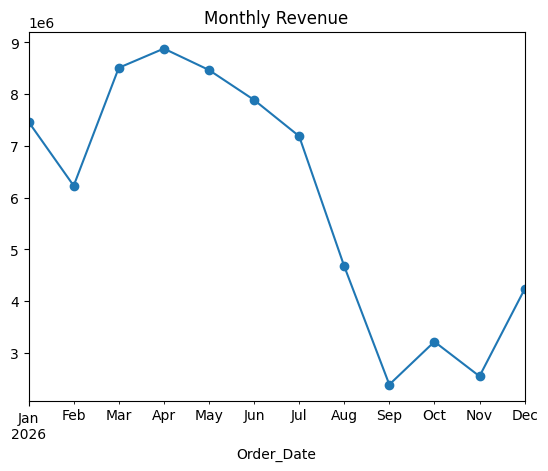

In [12]:
monthly_revenue = df.groupby(
    df['Order_Date'].dt.to_period('M')
)['Revenue'].sum()

monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue')
plt.show()

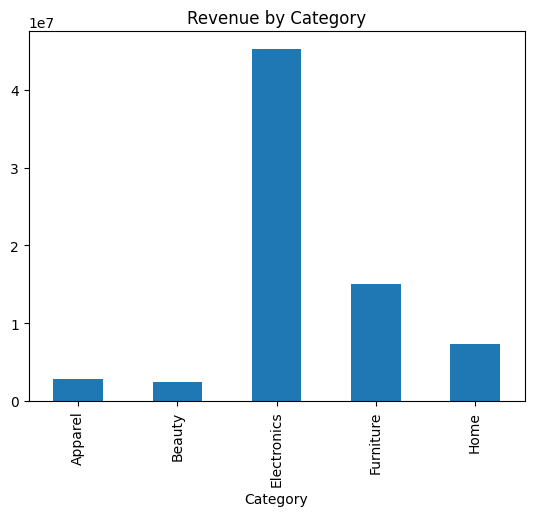

In [13]:
category_revenue = df.groupby('Category')['Revenue'].sum()

category_revenue.plot(kind='bar')
plt.title('Revenue by Category')
plt.show()

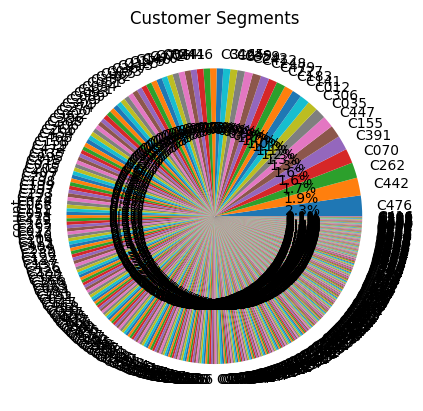

In [16]:
customer_segments = df['Customer_ID'].value_counts()

customer_segments.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Customer Segments')
plt.show()

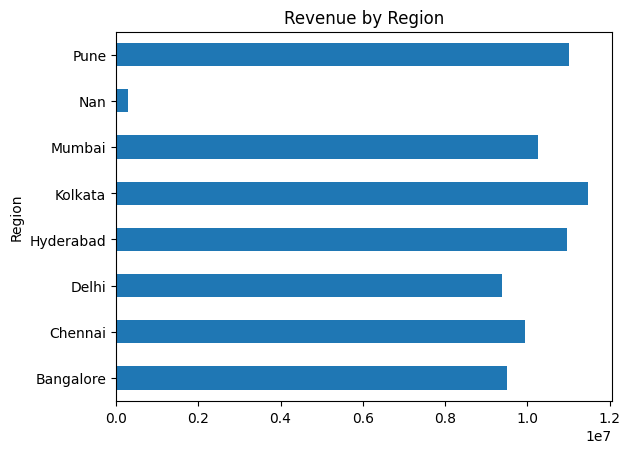

In [15]:
regional_revenue = df.groupby('Region')['Revenue'].sum()

regional_revenue.plot(kind='barh')
plt.title('Revenue by Region')
plt.show()

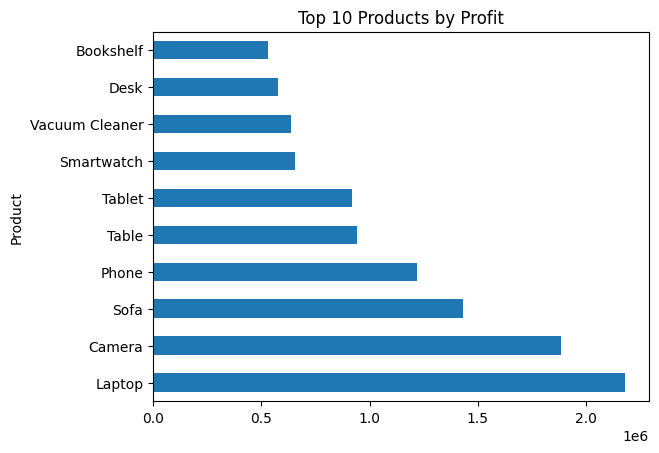

In [17]:
top_products = (
    df.groupby('Product')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='barh')
plt.title('Top 10 Products by Profit')
plt.show()

5 Observations

1. Monthly Revenue:
Revenue peaked in April 2026 and showed a significant decline in the later months.

2. Category Breakdown:
Electronics generated the highest total revenue, while Beauty generated the lowest revenue.

3. Customer Segment Split:
Repeat customers make up the larger share of customers compared with New Customers.

4. Regional Distribution:
Pune generated the highest revenue among the regions, while Bangalore had the lowest among the known regions.

5. Product Profitability:
Phone was the highest-profit named product.

 5 Insights

1. Extreme Revenue Seasonality:
The large difference between the highest- and lowest-revenue months indicates strong variation in monthly revenue.

2. Core Category Dependency:
Electronics contributes a very large share of total revenue compared with the other categories.

3. Customer Retention vs. Acquisition:
The customer base contains a much larger proportion of repeat customers than new customers.

4. Regional Revenue Distribution:
Revenue is spread across the regions, with noticeable differences between the highest- and lowest-revenue regions.

5. Data Quality Risk:
Blank or unlabeled product entries account for a large amount of profit, which can make product-level profitability analysis less reliable.

3 Hypotheses

1. Promotional Lulls:
The large drop in revenue in the later months might be related to changes or pauses in promotional and marketing activities.

2. Supply Chain Disruption:
The sharp decline in revenue might be caused by stockouts or inventory shortages in important product categories.

3. Product Catalog Changes:
Changes in product launches, product availability, or discount structures might have contributed to the large variation in monthly revenue.

3 Recommendations

1. Revenue Stability:
Investigate the reasons for large month-to-month revenue changes and review marketing, inventory, and product availability around low-revenue periods.

2. Customer Growth:
Develop initiatives to increase the number of new customers while maintaining engagement with existing repeat customers.

3. Product Data Quality:
Complete and standardize missing or blank product information so that product-level profit analysis is reliable.